Boston Housing Market data preparation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [27]:
df= pd.read_csv("../data/boston.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [28]:
df.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

In [29]:
df.shape

(506, 14)

In [30]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


Check Missing data

In [31]:
df.isna().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Check the outliers

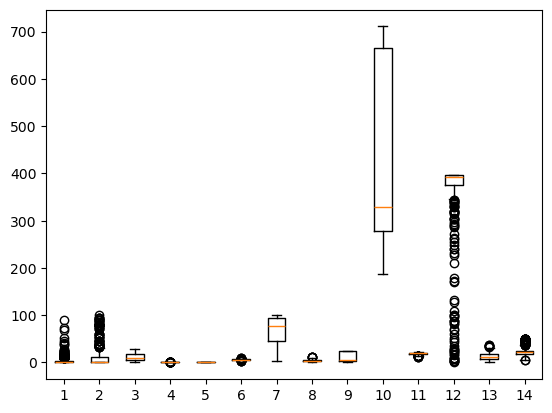

In [32]:
plt.boxplot(df)
plt.show()

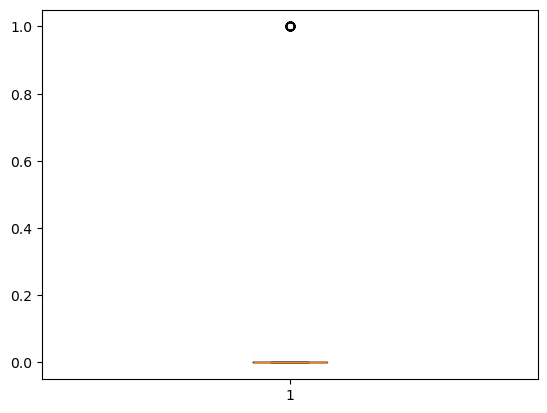

In [33]:
plt.boxplot(df[["CHAS"]])
plt.show()

In [34]:
df[["CHAS"]].describe()

,CHAS
count,506.000000
mean,0.069170
std,0.253994
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [35]:
df[df["CHAS"] == 1].count() 

CRIM       35
ZN         35
INDUS      35
CHAS       35
NOX        35
RM         35
AGE        35
DIS        35
RAD        35
TAX        35
PTRATIO    35
B          35
LSTAT      35
MEDV       35
dtype: int64

In [36]:
df.shape

(506, 14)

Standard Scaler

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
columns_to_scale = ["CRIM", "ZN", "INDUS", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B","LSTAT"]

scaler = StandardScaler()
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,-0.419782,0.284830,-1.287909,0,0.538,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,0.441052,-1.075562,24.0
1,-0.417339,-0.487722,-0.593381,0,0.469,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,0.441052,-0.492439,21.6
2,-0.417342,-0.487722,-0.593381,0,0.469,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,0.396427,-1.208727,34.7
3,-0.416750,-0.487722,-1.306878,0,0.458,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,0.416163,-1.361517,33.4
4,-0.412482,-0.487722,-1.306878,0,0.458,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,0.441052,-1.026501,36.2


In [39]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,5.060000e+02,5.060000e+02,5.060000e+02,506.000000,506.000000,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,506.000000,5.060000e+02,5.060000e+02,5.060000e+02,506.000000
mean,-1.123388e-16,7.898820e-17,2.106352e-16,0.069170,0.554695,-1.088282e-16,-1.474446e-16,-8.425408e-17,-1.123388e-16,0.000000,-4.212704e-16,-7.442444e-16,-3.089316e-16,22.532806
std,1.000990e+00,1.000990e+00,1.000990e+00,0.253994,0.115878,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990,1.000990e+00,1.000990e+00,1.000990e+00,9.197104
min,-4.197819e-01,-4.877224e-01,-1.557842e+00,0.000000,0.385000,-3.880249e+00,-2.335437e+00,-1.267069e+00,-9.828429e-01,-1.313990,-2.707379e+00,-3.907193e+00,-1.531127e+00,5.000000
25%,-4.109696e-01,-4.877224e-01,-8.676906e-01,0.000000,0.449000,-5.686303e-01,-8.374480e-01,-8.056878e-01,-6.379618e-01,-0.767576,-4.880391e-01,2.050715e-01,-7.994200e-01,17.025000
50%,-3.906665e-01,-4.877224e-01,-2.110985e-01,0.000000,0.538000,-1.084655e-01,3.173816e-01,-2.793234e-01,-5.230014e-01,-0.464673,2.748590e-01,3.811865e-01,-1.812536e-01,21.200000
75%,7.396560e-03,4.877224e-02,1.015999e+00,0.000000,0.624000,4.827678e-01,9.067981e-01,6.623709e-01,1.661245e+00,1.530926,8.065758e-01,4.336510e-01,6.030188e-01,25.000000
max,9.933931e+00,3.804234e+00,2.422565e+00,1.000000,0.871000,3.555044e+00,1.117494e+00,3.960518e+00,1.661245e+00,1.798194,1.638828e+00,4.410519e-01,3.548771e+00,50.000000


In [40]:
#df_for_boxplot = df.drop(columns=["MEDV"])
df_for_boxplot = df
df_for_boxplot.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,-0.419782,0.284830,-1.287909,0,0.538,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,0.441052,-1.075562,24.0
1,-0.417339,-0.487722,-0.593381,0,0.469,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,0.441052,-0.492439,21.6
2,-0.417342,-0.487722,-0.593381,0,0.469,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,0.396427,-1.208727,34.7
3,-0.416750,-0.487722,-1.306878,0,0.458,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,0.416163,-1.361517,33.4
4,-0.412482,-0.487722,-1.306878,0,0.458,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,0.441052,-1.026501,36.2


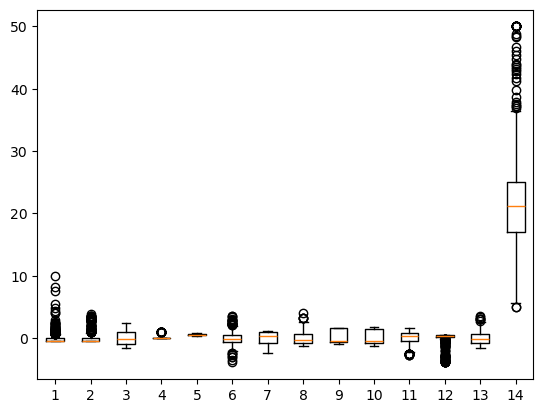

In [41]:
plt.boxplot(df_for_boxplot)
plt.show()

Remove outliers

1- Loop for outlier removal (It applys the same threshold to all)

In [42]:
columns_to_exclude = ["CHAS", "ZN", "B", "CRIM", "RM", "MEDV"]

In [43]:
for col in df_for_boxplot.columns:
    print(col)
    if col not in columns_to_exclude:
        df_col = df_for_boxplot[[col]]
        q1 = np.quantile(df_col, 0.25)
        q3 = np.quantile(df_col, 0.75)
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 *iqr)
        print(f"Lower bound: {lower_bound}")
        print(f"Q1: {q1}")
        print(f"Q3: {q3}")
        print(f"Upper bound: {upper_bound}")

        #remove the outliers
        df_for_boxplot = df_for_boxplot[(df_for_boxplot[col] >= lower_bound) 
                                        & (df_for_boxplot[col] <= upper_bound)] 
        print("--------------")


CRIM
ZN
INDUS
Lower bound: -3.6932250639495456
Q1: -0.8676905831448009
Q3: 1.0159990707250288
Upper bound: 3.8415335515297735
--------------
CHAS
NOX
Lower bound: 0.18650000000000005
Q1: 0.449
Q3: 0.624
Upper bound: 0.8865
--------------
RM
AGE
Lower bound: -3.453817029768927
Q1: -0.8374479538385027
Q3: 0.90679809678178
Upper bound: 3.523167172712204
--------------
DIS
Lower bound: -3.007775907119869
Q1: -0.8056877930150458
Q3: 0.6623709497215031
Upper bound: 2.8644590638263265
--------------
RAD
Lower bound: -4.086772378066552
Q1: -0.6379617988442783
Q3: 1.6612452539705709
Upper bound: 5.110055833192845
--------------
TAX
Lower bound: -4.215329734489365
Q1: -0.7675760181139194
Q3: 1.530926459469711
Upper bound: 4.978680175845157
--------------
PTRATIO
Lower bound: -2.4299616153761923
Q1: -0.4880391451782146
Q3: 0.8065758349537706
Upper bound: 2.7484983051517484
--------------
B
LSTAT
Lower bound: -2.8610258702841804
Q1: -0.7668295466883617
Q3: 0.6293013357088507
Upper bound: 2.7234976

In [44]:
df_for_boxplot.shape

(480, 14)

2- Manual outlier removal for extreme values of disperse distributions

In [45]:
#CRIM
q1 = np.quantile(df_for_boxplot["CRIM"], 0.25)
q3 = np.quantile(df_for_boxplot["CRIM"], 0.75)
iqr = q3 - q1
lower_bound = q1 - (6 * iqr)
upper_bound = q3 + (6 *iqr)
df_for_boxplot = df_for_boxplot[(df_for_boxplot["CRIM"]>= lower_bound) 
                                        & (df_for_boxplot["CRIM"] <= upper_bound)] 

In [46]:
df_for_boxplot["CRIM"].shape

(471,)

In [47]:
#RM
q1 = np.quantile(df_for_boxplot["RM"], 0.25)
q3 = np.quantile(df_for_boxplot["RM"], 0.75)
iqr = q3 - q1
lower_bound = q1 - (2.5 * iqr)
upper_bound = q3 + (2.5 *iqr)
df_for_boxplot = df_for_boxplot[(df_for_boxplot["RM"]>= lower_bound) 
                                        & (df_for_boxplot["RM"] <= upper_bound)] 

In [48]:
df_for_boxplot["RM"].shape

(465,)

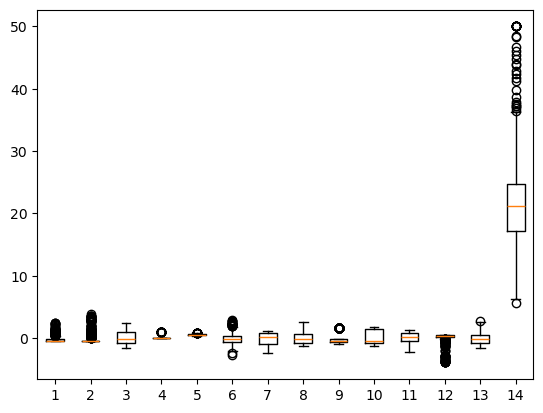

In [49]:
plt.boxplot(df_for_boxplot)
plt.show()

In [ ]:
#Save the data
df_for_boxplot.to_csv("../data/Boston_cleaned.csv")

: 